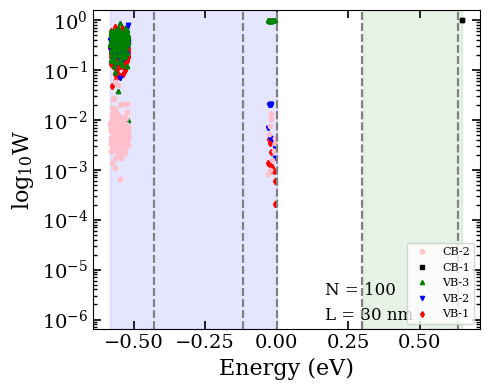

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh


import numpy as np
import matplotlib.pyplot as plt


# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})
N = n_states = 100
L = 300

NUM_VB_2,sigma_v2 = 250, -0.55
NUM_VB_1, sigma_v1 = 20, 0
NUM_CB, sigma_c = 2, 0.65
num_states_vb = NUM_VB_2 + NUM_VB_1
num_states_cb = NUM_CB



bulk_energy = np.loadtxt("bulk_energy_o.dat")

color_list = ["r", "b", "g", "k", "pink"]
legend_list = ["VB-1", "VB-2", "VB-3", "CB-1", "CB-2"]
symbol_list = ["d", "v", "^", "s", "o"]



evals_vb = np.loadtxt(f"energies_nw_vb_{N}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")[:num_states_vb][::-1]
evals_cb = np.loadtxt(f"energies_nw_cb_{N}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")[:num_states_cb]

full_energy = np.concatenate((evals_vb, evals_cb))

overlap_vb = np.loadtxt(f"overlap_vb_N{N}_states{num_states_vb}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")[::-1]
overlap_cb = np.loadtxt(f"overlap_cb_N{N}_states{num_states_cb}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat")


# bulk band summed over spin index
overlap_cb_spin_sum = np.array([
    overlap_cb[:, j] + overlap_cb[:, j + 1]
    for j in range(0, len(overlap_cb[0]), 2)
])

overlap_vb_spin_sum = np.array([
    overlap_vb[:, j] + overlap_vb[:, j + 1]
    for j in range(0, len(overlap_vb[0]), 2)
])

full_overlap_array = np.hstack((overlap_vb_spin_sum, overlap_cb_spin_sum))

saving_data = np.vstack((full_energy, full_overlap_array)).T
np.savetxt(f"energy_overlap_data_N{N}_o_numv2_{NUM_VB_2}_v2_{sigma_v2}_numv1_{NUM_VB_1}_v1_{sigma_v1}_numcb_{NUM_CB}_c_{sigma_c}.dat", saving_data)

# ---------------------------------------------------
# Figure
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 4))

# plots
for i in range(5):

    ax.plot(
        full_energy,
        full_overlap_array[i],
        symbol_list[i],
        label=legend_list[i],
        color=color_list[i],
        markersize=3
    )

# ---------------------------------------------------
# shaded regions
# ---------------------------------------------------

ax.axvspan(evals_vb[-1], 0,
           color='blue',
           alpha=0.10)

ax.axvspan(0.3, evals_cb[-1],
           color='green',
           alpha=0.10)

# ---------------------------------------------------
# labels
# ---------------------------------------------------

ax.set_xlabel("Energy (eV)", fontsize=16)
ax.set_ylabel(r"log$_{10}$W", fontsize=16)

# scales and limits
ax.set_yscale('log')

ax.set_ylim(10**-6.2, 10**0.2)
# ax.set_xlim(-0.2, 0.7)

# ---------------------------------------------------
# legend
# ---------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[::-1],
          labels[::-1],
          frameon=True,
          loc='lower right',
          fontsize=8,
          ncol=1)

# ---------------------------------------------------
# text
# ---------------------------------------------------

ax.text(0.60, 0.15,

        f"N = {N}",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

ax.text(0.60, 0.07,
        fr"L = {int(L/10)} nm",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

# ---------------------------------------------------
# vertical guide lines
# ---------------------------------------------------

for i in bulk_energy:

    ax.axvline(x=i,
               linestyle='--',
               color='gray')

# ---------------------------------------------------
# Tick styling
# ---------------------------------------------------

# Enable minor ticks
ax.minorticks_on()

# Major ticks
ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               width=1.2,
               labelsize=14)

# Minor ticks ONLY on y-axis (left/right)
ax.tick_params(axis='y',
               which='minor',
               direction='in',
               left=True,
               right=True,
               length=3,
               width=1.0)

# Disable x-axis minor ticks
ax.tick_params(axis='x',
               which='minor',
               bottom=False,
               top=False)

# ---------------------------------------------------
# grid
# ---------------------------------------------------

# ax.grid(alpha=0.3)

fig.tight_layout()

# save
fig.savefig(f"overlap_energy_log_scale_{N}.png", dpi=300)
fig.savefig(f"overlap_energy_log_scale_{N}.pdf")

plt.show()


In [2]:
saving_data.shape

(272, 6)

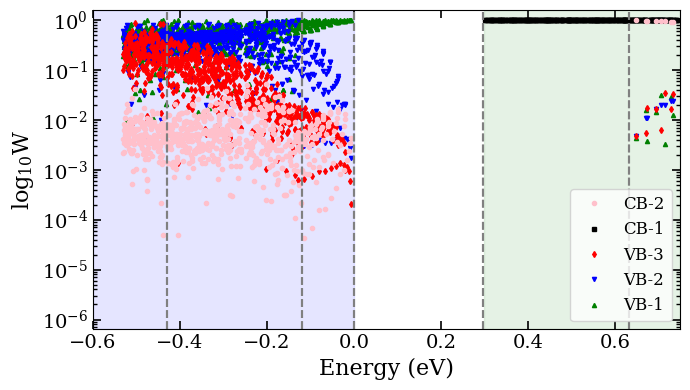

In [6]:
cb_levels = [0.3, 0.5, 0.65]

# =========================
# Load CB data
# =========================
all_cb_data = []

for cb in cb_levels:
    filename = f"energy_overlap_data_N100_o_numv2_2_v2_-0.1_numv1_20_v1_0_numcb_250_c_{cb}.dat"
    data = np.loadtxt(filename)
    all_cb_data.append(data)

# Stack all CB data
combined_cb_data = np.vstack(all_cb_data)
# print(combined_data[combined_data[:,0]>0])


vb_levels = [0]
# =========================
# Load VB data
# =========================
all_vb_data = []

for vb in vb_levels:
    filename = f"energy_overlap_data_N100_o_numv2_2_v2_-0.1_numv1_250_v1_{vb}_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data.append(data)

# Stack all VB data
combined_vb_data = np.vstack(all_vb_data)


vb_levels_2 = [-0.2, -0.3, -0.35, -0.4, -0.45, -0.5]#, -0.55]
# =========================
# Load VB data
# =========================
all_vb_data_2 = []

for vb in vb_levels_2:
    filename = f"energy_overlap_data_N100_o_numv2_250_v2_{vb}_numv1_20_v1_0_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data_2.append(data)

# Stack all VB data
combined_vb_data_2 = np.vstack(all_vb_data_2)




# # =========================
# # Stack CB + VB data together
# # =========================
combined_data = np.vstack([combined_cb_data, combined_vb_data, combined_vb_data_2])


# Sort by energy column
combined_data = combined_data[np.argsort(combined_data[:, 0])]



# Remove repeated energy values
rounded_energy = np.round(combined_data[:, 0], decimals=10)
_, unique_indices = np.unique(rounded_energy, return_index=True)

clean_data = combined_data[unique_indices]

# Sort again after removing duplicates
clean_data = clean_data[np.argsort(clean_data[:, 0])]



# ---------------------------------------------------
# Figure
# ---------------------------------------------------

color_list = ["r", "b", "g", "k", "pink"]
legend_list = ["VB-1", "VB-2", "VB-3", "CB-1", "CB-2"]
symbol_list = ["d", "v", "^", "s", "o"]

fig, ax = plt.subplots(figsize=(7, 4))

# plots
for i in range(2,-1,-1):

    ax.plot(
        clean_data[:, 0],
        clean_data[:, i + 1],
        symbol_list[i],
        label=legend_list[abs(i-2)],
        color=color_list[i],
        markersize=3
    )


for i in range(3,5):

    ax.plot(
        clean_data[:, 0],
        clean_data[:, i + 1],
        symbol_list[i],
        label=legend_list[i],
        color=color_list[i],
        markersize=3
    )
# ---------------------------------------------------
# shaded regions
# ---------------------------------------------------

ax.axvspan(-0.6, 0, color='blue', alpha=0.1)
ax.axvspan(0.3, 0.75, color='green', alpha=0.1)

# ---------------------------------------------------
# labels
# ---------------------------------------------------

ax.set_xlabel("Energy (eV)", fontsize=16)
ax.set_ylabel(r"log$_{10}$W", fontsize=16)

# scales and limits
ax.set_yscale('log')

ax.set_ylim(10**-6.2, 10**0.2)
ax.set_xlim(-0.6, 0.75)

# ---------------------------------------------------
# legend
# ---------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[::-1],
          labels[::-1],
          frameon=True,
          loc='lower right',
          fontsize=12,
          ncol=1)

# ---------------------------------------------------
# text
# ---------------------------------------------------

# ax.text(0.60, 0.15,

#         f"N = {N}",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# ax.text(0.60, 0.07,
#         fr"L = {int(L/10)} nm",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# ---------------------------------------------------
# vertical guide lines
# ---------------------------------------------------

for i in bulk_energy:

    ax.axvline(x=i,
               linestyle='--',
               color='gray')

# ---------------------------------------------------
# Tick styling
# ---------------------------------------------------

# Enable minor ticks
ax.minorticks_on()

# Major ticks
ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               width=1.2,
               labelsize=14)

# Minor ticks ONLY on y-axis (left/right)
ax.tick_params(axis='y',
               which='minor',
               direction='in',
               left=True,
               right=True,
               length=3,
               width=1.0)

# Disable x-axis minor ticks
ax.tick_params(axis='x',
               which='minor',
               bottom=False,
               top=False)

# ---------------------------------------------------
# grid
# ---------------------------------------------------

# ax.grid(alpha=0.3)

fig.tight_layout()

# save
fig.savefig(f"full_range_overlap_energy_log_scale_{N}.png", dpi=300)
fig.savefig(f"full_range_overlap_energy_log_scale_{N}.pdf")

plt.show()


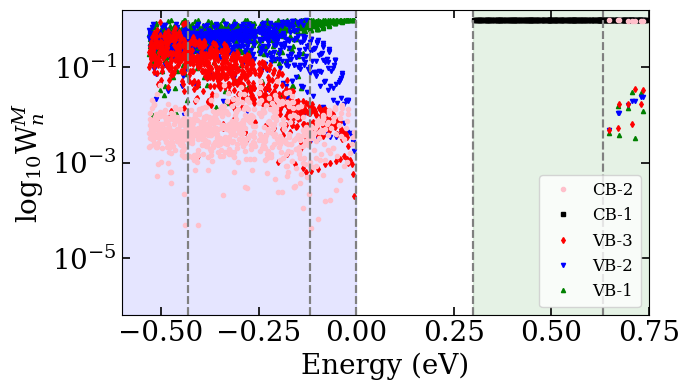

In [10]:
#for poster
cb_levels = [0.3, 0.5, 0.65]

# =========================
# Load CB data
# =========================
all_cb_data = []

for cb in cb_levels:
    filename = f"energy_overlap_data_N100_o_numv2_2_v2_-0.1_numv1_20_v1_0_numcb_250_c_{cb}.dat"
    data = np.loadtxt(filename)
    all_cb_data.append(data)

# Stack all CB data
combined_cb_data = np.vstack(all_cb_data)
# print(combined_data[combined_data[:,0]>0])


vb_levels = [0]
# =========================
# Load VB data
# =========================
all_vb_data = []

for vb in vb_levels:
    filename = f"energy_overlap_data_N100_o_numv2_2_v2_-0.1_numv1_250_v1_{vb}_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data.append(data)

# Stack all VB data
combined_vb_data = np.vstack(all_vb_data)


vb_levels_2 = [-0.2, -0.3, -0.35, -0.4, -0.45, -0.5]#, -0.55]
# =========================
# Load VB data
# =========================
all_vb_data_2 = []

for vb in vb_levels_2:
    filename = f"energy_overlap_data_N100_o_numv2_250_v2_{vb}_numv1_20_v1_0_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data_2.append(data)

# Stack all VB data
combined_vb_data_2 = np.vstack(all_vb_data_2)




# # =========================
# # Stack CB + VB data together
# # =========================
combined_data = np.vstack([combined_cb_data, combined_vb_data, combined_vb_data_2])


# Sort by energy column
combined_data = combined_data[np.argsort(combined_data[:, 0])]



# Remove repeated energy values
rounded_energy = np.round(combined_data[:, 0], decimals=10)
_, unique_indices = np.unique(rounded_energy, return_index=True)

clean_data = combined_data[unique_indices]

# Sort again after removing duplicates
clean_data = clean_data[np.argsort(clean_data[:, 0])]



# ---------------------------------------------------
# Figure
# ---------------------------------------------------

color_list = ["r", "b", "g", "k", "pink"]
legend_list = ["VB-1", "VB-2", "VB-3", "CB-1", "CB-2"]
symbol_list = ["d", "v", "^", "s", "o"]

fig, ax = plt.subplots(figsize=(7, 4))

# plots
for i in range(2,-1,-1):

    ax.plot(
        clean_data[:, 0],
        clean_data[:, i + 1],
        symbol_list[i],
        label=legend_list[abs(i-2)],
        color=color_list[i],
        markersize=3
    )


for i in range(3,5):

    ax.plot(
        clean_data[:, 0],
        clean_data[:, i + 1],
        symbol_list[i],
        label=legend_list[i],
        color=color_list[i],
        markersize=3
    )
# ---------------------------------------------------
# shaded regions
# ---------------------------------------------------

ax.axvspan(-0.6, 0, color='blue', alpha=0.1)
ax.axvspan(0.3, 0.75, color='green', alpha=0.1)

# ---------------------------------------------------
# labels
# ---------------------------------------------------

ax.set_xlabel("Energy (eV)", fontsize=20)
ax.set_ylabel(r"log$_{10}$W$_n^M$", fontsize=20)

# scales and limits
ax.set_yscale('log')

ax.set_ylim(10**-6.2, 10**0.2)
ax.set_xlim(-0.6, 0.75)

# ---------------------------------------------------
# legend
# ---------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles[::-1],
          labels[::-1],
          frameon=True,
          loc='lower right',
          fontsize=12,
          ncol=1)

# ---------------------------------------------------
# text
# ---------------------------------------------------

# ax.text(0.60, 0.15,

#         f"N = {N}",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# ax.text(0.60, 0.07,
#         fr"L = {int(L/10)} nm",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# ---------------------------------------------------
# vertical guide lines
# ---------------------------------------------------

for i in bulk_energy:

    ax.axvline(x=i,
               linestyle='--',
               color='gray')

# ---------------------------------------------------
# Tick styling
# ---------------------------------------------------

# Enable minor ticks
ax.minorticks_on()

# Major ticks
ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               width=1.2,
               labelsize=20)

# Minor ticks ONLY on y-axis (left/right)
ax.tick_params(axis='y',
               which='minor',
               direction='in',
               left=True,
               right=True,
               length=3,
               width=1.0)

# Disable x-axis minor ticks
ax.tick_params(axis='x',
               which='minor',
               bottom=False,
               top=False)

# ---------------------------------------------------
# grid
# ---------------------------------------------------

# ax.grid(alpha=0.3)

fig.tight_layout()

# save
fig.savefig(f"full_range_overlap_energy_log_scale_{N}.png", dpi=300)
fig.savefig(f"full_range_overlap_energy_log_scale_{N}.pdf")

plt.show()


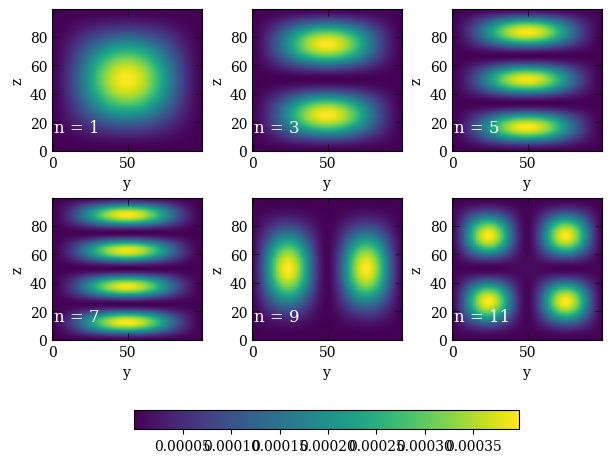

In [4]:
""""TOP 6 2D density plots of psi^n_{yz} for n = 1,3,5,7,9,11 (every 2nd state)"""

psi_density = np.loadtxt(f"psi_data_vb_{N}_o.dat")[::-1]
    
# Number of plots
n_plots = 6
rows, cols = 2, 3
band_idx = np.array([[1,1,2,2,3,3],[4,4,5,5,6,6]])
fig, axs = plt.subplots(rows, cols, figsize=(6, 4.5), constrained_layout=True)
axs = axs.flatten()  # Flatten to easily index in 1D

for i, n in enumerate(range(0, 12, 2)):  # Plot every 2nd state from 0 to 10
    if n < psi_density.shape[0]:
        psi_2d = psi_density[n].reshape((N, N)).T  # Assuming square shape
        im = axs[i].imshow(psi_2d, cmap='viridis', origin='lower',
                            aspect='auto')
        axs[i].tick_params(direction='in', length=5, width=0.5, colors='k',
                            bottom=True, top=True, left=True, right=True)
        axs[i].set_xlabel("y")
        axs[i].set_ylabel("z")
        axs[i].text(1, 13, f"n = {n+1}", color='white', fontsize=12)
        # axs[i].set_yticks([1,5,9,13])
        # axs[i].set_xticks([1,5,9,13])

    else:
        axs[i].axis('off')

cbar = fig.colorbar(im, ax=axs, orientation='horizontal', shrink=0.7, pad=0.08)
# cbar.set_label(r"Probability Density $|\sum_{j}\\psi^n_{yz}|^2$")
plt.show()

# plt.savefig(f"psi_density_{N}.png", dpi=300)
# plt.savefig(f"psi_density_{N}.pdf")

In [5]:
"""FOR Y DIERCTIONAL FIELD"""

np.set_printoptions(suppress=True, precision=5, linewidth=1000)

overlap_cb = np.loadtxt(f"overlap_cb_N{N}_states{num_states_cb}_o.dat")
overlap_vb = np.loadtxt(f"overlap_vb_N{N}_states{num_states_vb}_o.dat")

# path = r"c:\\Users\\Anirban\\Dropbox\\he-ge\\rashbha\\kwant\\Rashbha_coeff\\real_space\\SW_real_space\\matrix_elements\\Y\\"

vb_data = np.loadtxt(f"important_valence_subbands_data_N{N}.dat",skiprows=1)
cb_data = np.loadtxt(f"important_conduction_subbands_data_N{N}.dat",skiprows=1)

overlap_cb_spin_sum = np.array([
    overlap_cb[:, j] + overlap_cb[:, j + 1]
    for j in range(0, len(overlap_cb[0]), 2)
])

overlap_vb_spin_sum = np.array([
    overlap_vb[:, j] + overlap_vb[:, j + 1]
    for j in range(0, len(overlap_vb[0]), 2)
])

list_of_vsb = vb_data[:,0].astype(int)
list_of_csb = cb_data[:,0].astype(int)

full_index_list = np.concatenate((list_of_vsb, list_of_csb))

list_of_energies = np.concatenate((vb_data[:,1], cb_data[:,1]))
list_of_percentage = np.concatenate((vb_data[:,4], cb_data[:,4]))



major_valence_subbands = np.array([overlap_vb_spin_sum[:,i] for i in list_of_vsb])
major_conduction_subbands = np.array([overlap_cb_spin_sum[:,i] for i in list_of_csb])
important_subbands = np.column_stack((major_valence_subbands.T, major_conduction_subbands.T ))



heading = ["index", "energy(eV)","change(%)","vb3","vb2","vb1","cb1","cb2"]
data = np.vstack((full_index_list, list_of_energies, list_of_percentage, important_subbands)).T

print(heading)
print(data)

# np.savetxt(
#     "important_subbands_data.dat",
#     data,
#     fmt="%.6f",
#     header=" ".join(heading),
#     comments=''
# )


np.savetxt(
    "important_subbands.csv",
    data,
    delimiter=",",
    fmt="%.6f",
    header=",".join(heading),
    comments=""
)




FileNotFoundError: overlap_cb_N100_states2_o.dat not found.

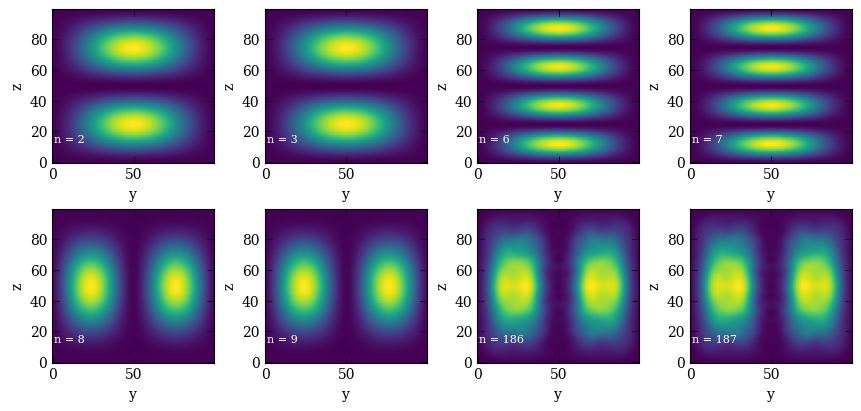

In [ ]:
"""Valence band density plots for important subbands (Z directional field)"""

psi_density = np.loadtxt(f"psi_data_vb_{N}_o.dat")[::-1]
psi_density.shape
    

# Number of plots
n_plots = len(list_of_vsb)
rows, cols = 2, 4
band_idx = np.array([[1,1,2,2,3,3],[4,4,5,5,6,6]])
fig, axs = plt.subplots(rows, cols, figsize=(8.5, 4), constrained_layout=True)
axs = axs.flatten()  # Flatten to easily index in 1D

for i, n in enumerate(list_of_vsb):
    if n < psi_density.shape[0]:
        psi_2d = psi_density[n].reshape((N, N)).T  # Assuming square shape
        im = axs[i].imshow(psi_2d, cmap='viridis', origin='lower',
                            aspect='auto')
        axs[i].tick_params(direction='in', length=5, width=0.5, colors='k',
                            bottom=True, top=True, left=True, right=True)
        axs[i].set_xlabel("y")
        axs[i].set_ylabel("z")
        axs[i].text(1, 13, f"n = {n}", color='white', fontsize=8)
        # axs[i].set_yticks([1,5,9,13])
        # axs[i].set_xticks([1,5,9,13])

    else:
        axs[i].axis('off')

# cbar = fig.colorbar(im, ax=axs, orientation='horizontal', shrink=0.7, pad=0.08)
# cbar.set_label(r"Probability Density $|\sum_{j}\\psi^n_{yz}|^2$")
plt.show()

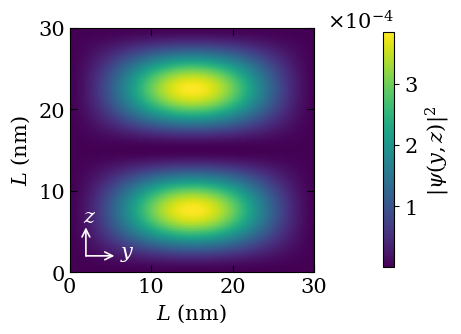

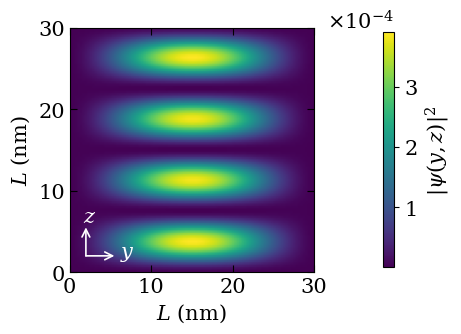

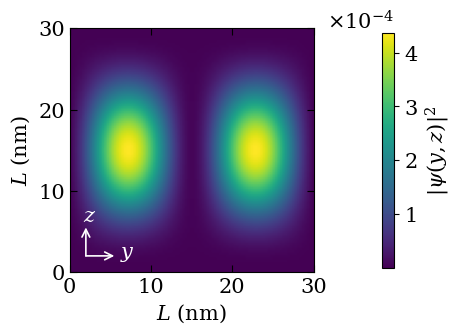

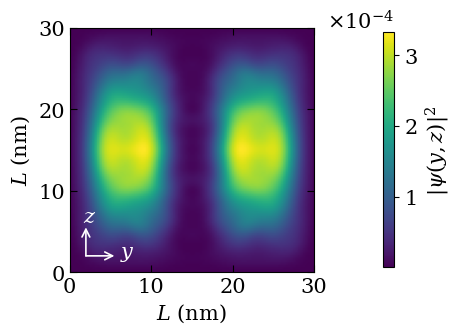

In [ ]:
"""Valence band density plots for important subbands (Z directional field) individual plots"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# -----------------------------
# Parameters
# -----------------------------
L_nm = 30.0
Ny = Nz = N

# -----------------------------
# Load density
# -----------------------------
psi_density = np.loadtxt(f"psi_data_vb_{N}_o.dat")[::-1]

# -----------------------------
# Plot each selected state separately
# -----------------------------
for i, n in enumerate(list_of_vsb[::2]):
    if n < psi_density.shape[0]:

        psi_2d = psi_density[n].reshape((Ny, Nz)).T

        fig, ax = plt.subplots(1, 1, figsize=(4.5, 4), constrained_layout=True)

        im = ax.imshow(
            psi_2d,
            cmap='viridis',
            origin='lower',
            extent=[0, L_nm, 0, L_nm],
            aspect='equal'
        )

        # Tick style
        ax.tick_params(
            direction='in',
            length=5,
            width=0.8,
            colors='k',
            bottom=True,
            top=True,
            left=True,
            right=True,
            labelsize=15
        )

        # Axis labels
        ax.set_xlabel(r"$L$ (nm)", fontsize=15)
        ax.set_ylabel(r"$L$ (nm)", fontsize=15)

        # State label inside the plot
        # ax.text(1.2, 27.0, f"n = {n}", color='white', fontsize=15)

        # -----------------------------
        # Joined y-z arrows inside plot
        # -----------------------------
        x0, z0 = 2.0, 2.0
        arrow_len = 3.5

        # y arrow
        ax.annotate(
            "",
            xy=(x0 + arrow_len, z0),
            xytext=(x0, z0),
            arrowprops=dict(
                arrowstyle="->",
                color="white",
                lw=1.2,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=14
            )
        )

        # z arrow
        ax.annotate(
            "",
            xy=(x0, z0 + arrow_len),
            xytext=(x0, z0),
            arrowprops=dict(
                arrowstyle="->",
                color="white",
                lw=1.2,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=14
            )
        )

        ax.text(x0 + arrow_len + 0.7, z0 - 0.2, r"$y$", color="white", fontsize=15)
        ax.text(x0 - 0.35, z0 + arrow_len + 0.7, r"$z$", color="white", fontsize=15)

        # -----------------------------
        # Colorbar in scientific notation
        # -----------------------------
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))

        cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.6, pad=0.0)
        cbar.set_label(r"$|\psi(y,z)|^2$", fontsize=15)
        cbar.formatter = formatter
        cbar.update_ticks()
        cbar.ax.tick_params(labelsize=15)

        # Optional: make the exponent text size nicer
        cbar.ax.yaxis.get_offset_text().set_size(15)

        # Save each plot separately
        plt.savefig(f"important_vb_n{n}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"important_vb_n{n}.pdf", bbox_inches="tight")

        plt.show()

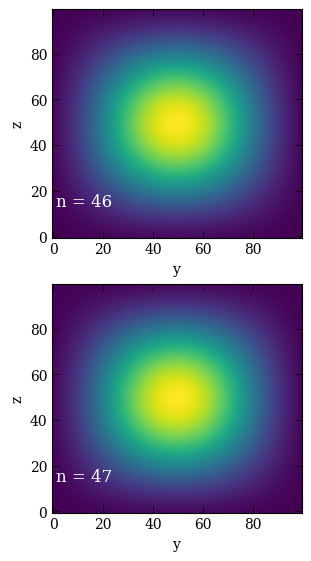

In [ ]:
""" Conduction band density plots for important subbands (Z directional field)"""
psi_density = np.loadtxt(f"psi_data_cb_{N}_o.dat")
psi_density.shape
    

# Number of plots
n_plots = len(list_of_csb)
rows, cols = 2, 1
band_idx = np.array([[1,1,2,2,3,3],[4,4,5,5,6,6]])
fig, axs = plt.subplots(rows, cols, figsize=(3, 5.5), constrained_layout=True)
axs = axs.flatten()  # Flatten to easily index in 1D

for i, n in enumerate(list_of_csb):
    if n < psi_density.shape[0]:
        psi_2d = psi_density[n].reshape((N, N)).T  # Assuming square shape
        im = axs[i].imshow(psi_2d, cmap='viridis', origin='lower',
                            aspect='auto')
        axs[i].tick_params(direction='in', length=5, width=0.5, colors='k',
                            bottom=True, top=True, left=True, right=True)
        axs[i].set_xlabel("y")
        axs[i].set_ylabel("z")
        axs[i].text(1, 13, f"n = {n}", color='white', fontsize=12)
        # axs[i].set_yticks([1,5,9,13])
        # axs[i].set_xticks([1,5,9,13])

    else:
        
        axs[i].axis('off')

# cbar = fig.colorbar(im, ax=axs, orientation='horizontal', shrink=0.7, pad=0.08)
# cbar.set_label(r"Probability Density $|\sum_{j}\\psi^n_{yz}|^2$")
plt.show()

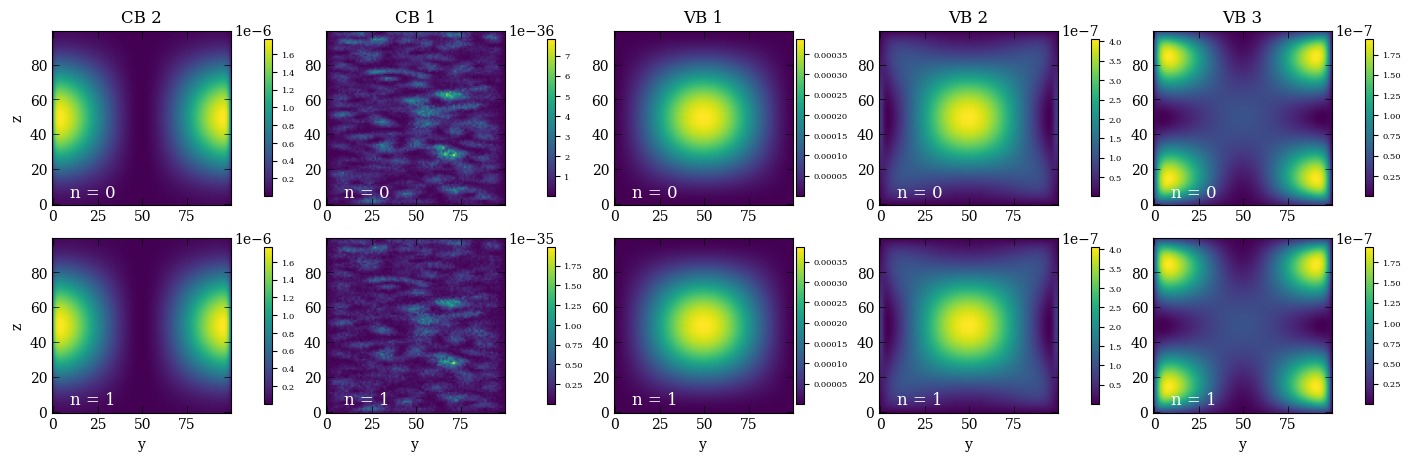

In [ ]:
"""orbital resolved top vb"""

# path = r"D:\\BME\\Z\\"
psi_density = np.loadtxt(f"psi_data_vb_orbital_{N}_o.dat")[::-1].T

vb_list = [0,1]

def psi_density_orb(n_vector, orbital): 
    return np.array([(psi_density[:, n_vector][i] + psi_density[:, n_vector][i+5]) 
                     for i in range(orbital, psi_density.shape[0], 10)])

fig, axs = plt.subplots(2, 5, figsize=(14, 4.5), constrained_layout=True)

titles = ["CB 2", "CB 1", "VB 1", "VB 2", "VB 3"]

for row, vb in enumerate(vb_list):
    psi_2d_list = [
        psi_density_orb(vb, orbital).reshape((N, N)).T
        for orbital in range(0, 5)
    ]

    for col, (ax, psi_2d) in enumerate(zip(axs[row], psi_2d_list)):
        im = ax.imshow(psi_2d, cmap='viridis', origin='lower', aspect='auto')
        ax.tick_params(direction='in', length=5, width=0.5, colors='k',
                       bottom=True, top=True, left=True, right=True)

        # Individual colorbar per panel
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
        cbar.ax.tick_params(labelsize=6)

        label = vb_list[1] if row == 1 else vb_list[0]
        if row == 1:
            ax.set_xlabel("y")
        ax.text(0.10, 0.12, fr"n = {label}",
                transform=ax.transAxes, fontsize=12,
                verticalalignment='top', color='w')
        if col == 0:
            ax.set_ylabel("z")
        if row == 0:
            ax.set_title(titles[col])

plt.savefig("orbital_resolved_top_vsb.png",dpi = 300)
plt.show()



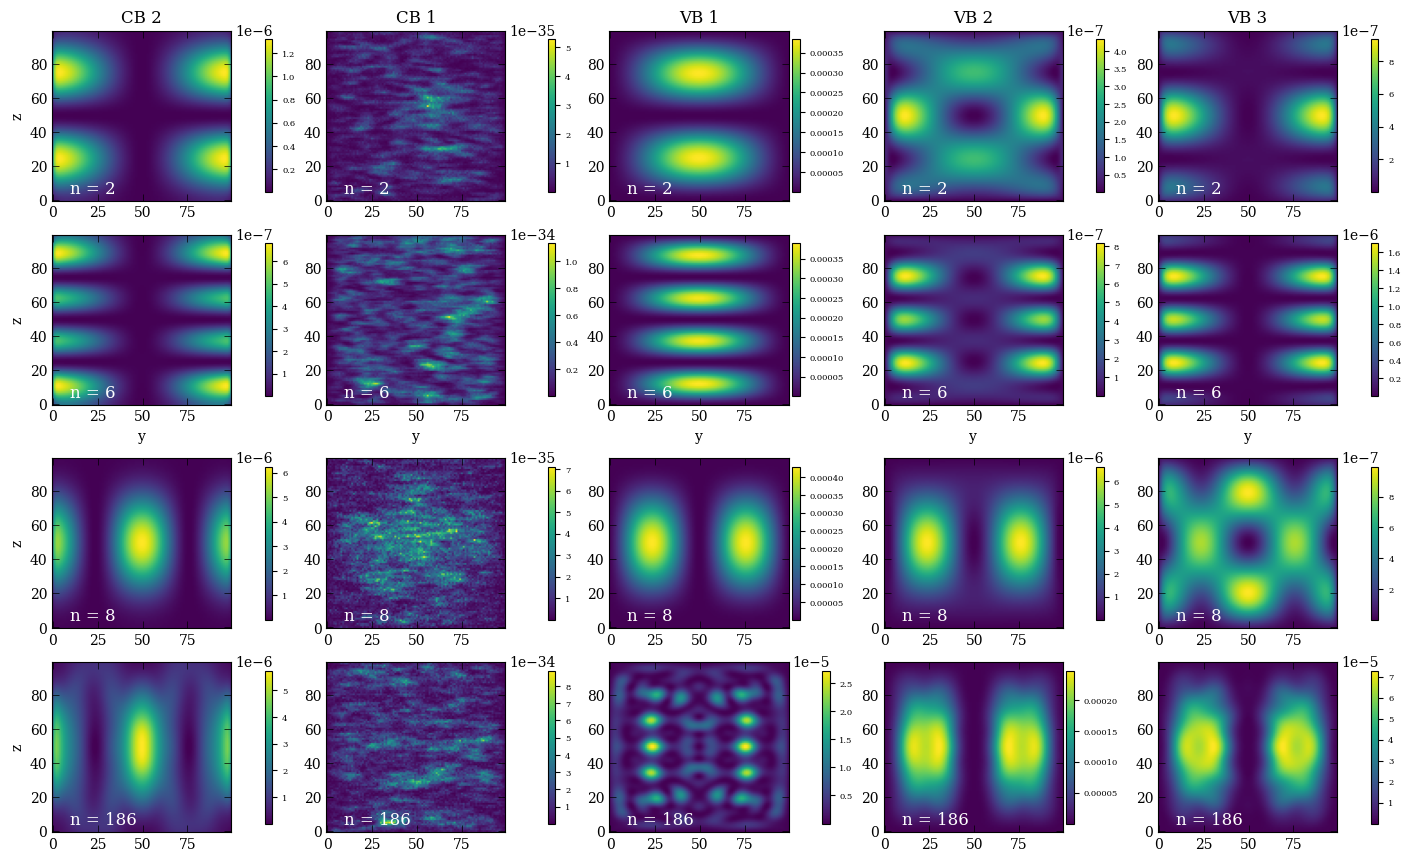

In [ ]:
"""orbital resolved other vb"""
# path = r"D:\\BME\\Z\\"
psi_density = np.loadtxt(f"psi_data_vb_orbital_{N}_o.dat")[::-1].T

vb_list = list_of_vsb[::2]  #select every alternate subband

def psi_density_orb(n_vector, orbital): 
    return np.array([(psi_density[:, n_vector][i] + psi_density[:, n_vector][i+5]) 
                     for i in range(orbital, psi_density.shape[0], 10)])

fig, axs = plt.subplots(4, 5, figsize=(14, 8.5), constrained_layout=True)

titles = ["CB 2", "CB 1", "VB 1", "VB 2", "VB 3"]

for row, vb in enumerate(vb_list):
    psi_2d_list = [
        psi_density_orb(vb, orbital).reshape((N, N)).T
        for orbital in range(0, 5)
    ]

    for col, (ax, psi_2d) in enumerate(zip(axs[row], psi_2d_list)):
        im = ax.imshow(psi_2d, cmap='viridis', origin='lower', aspect='auto')
        ax.tick_params(direction='in', length=5, width=0.5, colors='k',
                       bottom=True, top=True, left=True, right=True)

        # Individual colorbar per panel
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
        cbar.ax.tick_params(labelsize=6)

        # label = vb_list[1] if row == 1 else vb_list[0]
        if row == 1:
            ax.set_xlabel("y")
        ax.text(0.10, 0.12, fr"n = {vb_list[row]}",
                transform=ax.transAxes, fontsize=12,
                verticalalignment='top', color='w')
        if col == 0:
            ax.set_ylabel("z")
        if row == 0:
            ax.set_title(titles[col])
plt.savefig("orbital_resolved_other_vsb.pdf",dpi = 300)
plt.savefig("orbital_resolved_other_vsb.png",dpi = 300)
plt.show()

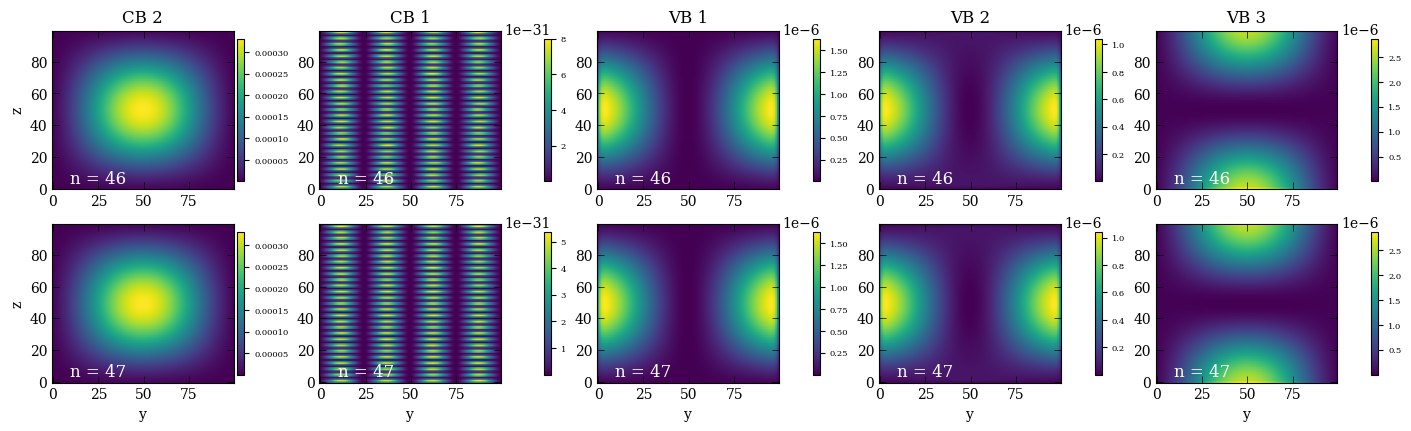

In [ ]:
# path = r"D:\\BME\\Z\\"
psi_density = np.loadtxt(f"psi_data_cb_orbital_{N}_o.dat").T

cb_list = list_of_csb  #select every alternate subband

def psi_density_orb(n_vector, orbital): 
    return np.array([(psi_density[:, n_vector][i] + psi_density[:, n_vector][i+5]) 
                     for i in range(orbital, psi_density.shape[0], 10)])

fig, axs = plt.subplots(2, 5, figsize=(14, 4.2), constrained_layout=True)

titles = ["CB 2", "CB 1", "VB 1", "VB 2", "VB 3"]

for row, cb in enumerate(cb_list):
    psi_2d_list = [
        psi_density_orb(cb, orbital).reshape((N, N)).T
        for orbital in range(0, 5)
    ]

    for col, (ax, psi_2d) in enumerate(zip(axs[row], psi_2d_list)):
        im = ax.imshow(psi_2d, cmap='viridis', origin='lower', aspect='auto')
        ax.tick_params(direction='in', length=5, width=0.5, colors='k',
                       bottom=True, top=True, left=True, right=True)
        # Individual colorbar per panel
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
        cbar.ax.tick_params(labelsize=6)
        if row == 1:
            ax.set_xlabel("y")
            ax.text(0.10, 0.12,
                    fr"n = {cb_list[1]}",
                    transform=ax.transAxes,
                    fontsize=12,
                    verticalalignment='top',
                    color = 'w')
        else:
            ax.text(0.10, 0.12,
                    fr"n = {cb_list[0]}",
                    transform=ax.transAxes,
                    fontsize=12,
                    verticalalignment='top',
                    color = 'w')
        if col == 0:
            ax.set_ylabel("z")
        if row == 0:
            ax.set_title(titles[col])
plt.savefig("orbital_resolved_cb.png",dpi = 300)
plt.savefig("orbital_resolved_cb.pdf",dpi = 300)
plt.show()